In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
from google.colab import files
uploaded = files.upload()

Saving Student Social Media And Mental Health Impact.csv to Student Social Media And Mental Health Impact (1).csv


In [13]:
df = pd.read_csv("Student Social Media And Mental Health Impact.csv")

In [14]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [15]:
df.shape

(5000, 13)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [17]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [18]:
df.duplicated().sum()
df[df.duplicated()]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
2405,19,Female,Other,Undergraduate,LinkedIn,Education,6.1,202,1.0,2.1,5.8,High,4.1
2463,21,Male,USA,Undergraduate,Snapchat,Entertainment,3.9,126,5.1,2.6,7.1,Low,7.5


In [19]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

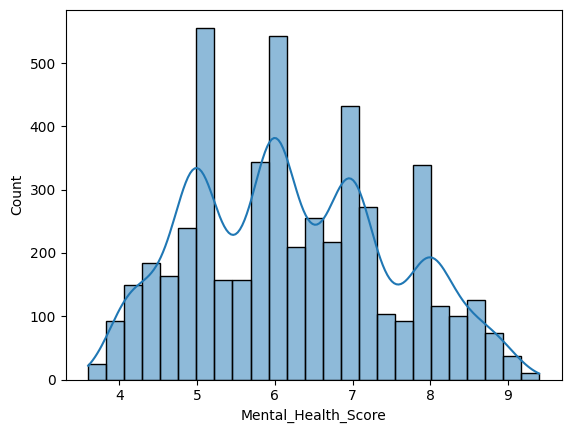

In [20]:
sns.histplot(df['Mental_Health_Score'], kde=True)

<Axes: >

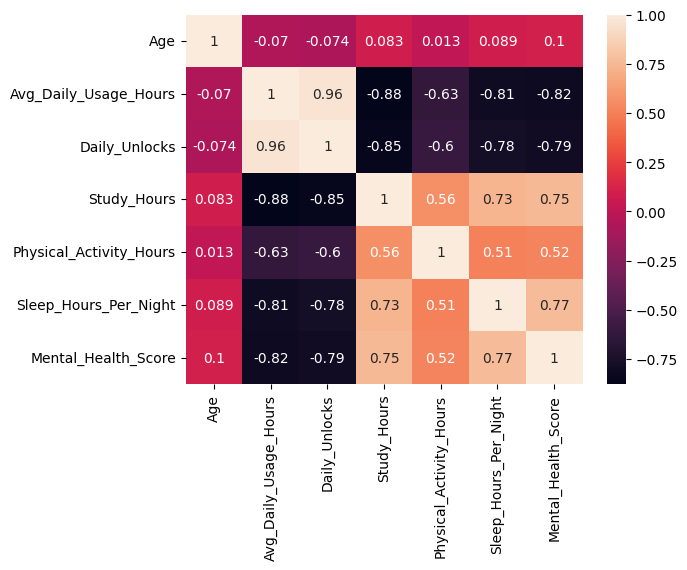

In [21]:
sns.heatmap(df.corr(numeric_only=True),annot=True,)

In [22]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

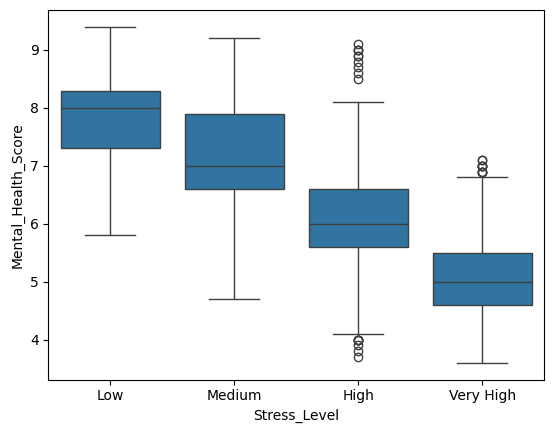

In [23]:
order=['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level',y='Mental_Health_Score',data=df,order=order)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

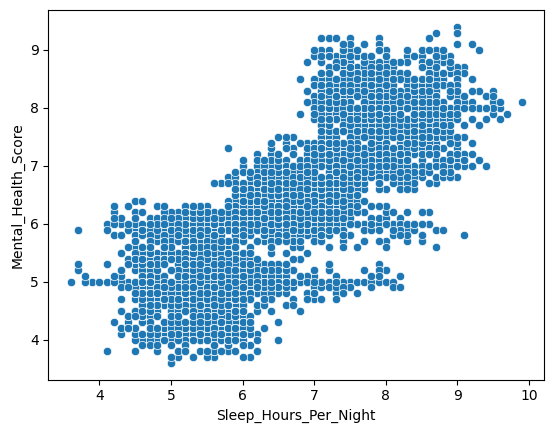

In [24]:
sns.scatterplot(x='Sleep_Hours_Per_Night',y='Mental_Health_Score',data=df)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

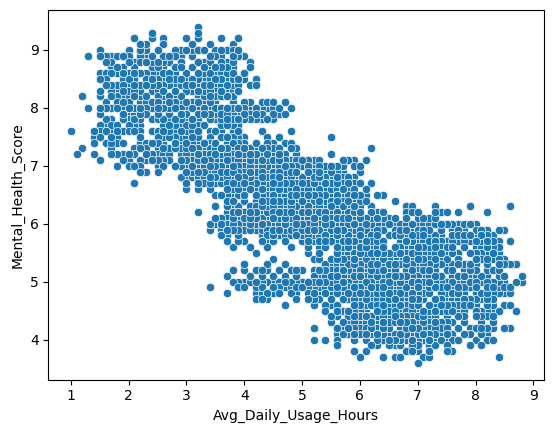

In [25]:
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score',data=df)

<Axes: xlabel='Study_Hours', ylabel='Mental_Health_Score'>

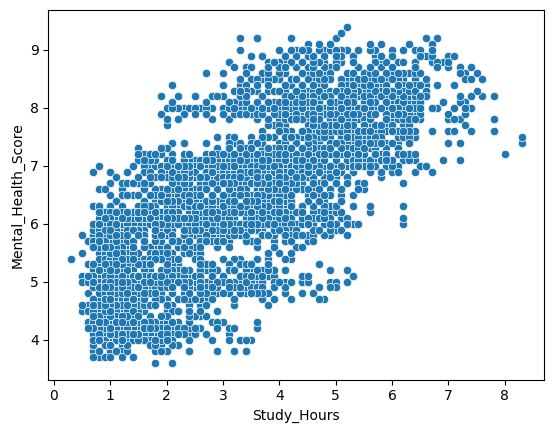

In [26]:
sns.scatterplot(x='Study_Hours',y='Mental_Health_Score',data=df)

In [27]:
df[['Study_Hours', 'Mental_Health_Score']].corr()

,Study_Hours,Mental_Health_Score
Study_Hours,1.000000,0.752626
Mental_Health_Score,0.752626,1.000000


In [28]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [29]:
df['Most_Used_Platform'].value_counts()


,count
Most_Used_Platform,
Instagram,1130
TikTok,918
Facebook,719
LinkedIn,523
YouTube,491
Twitter,462
Snapchat,420
WhatsApp,175
LINE,50


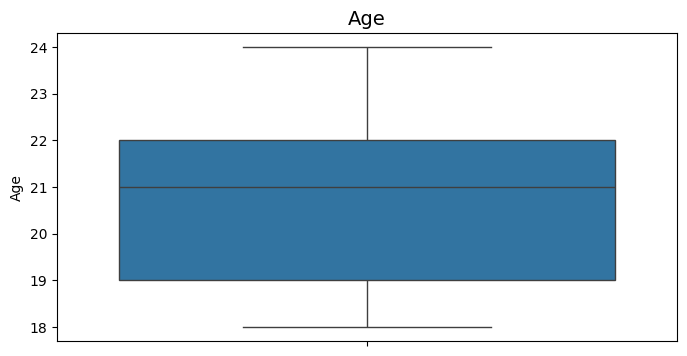

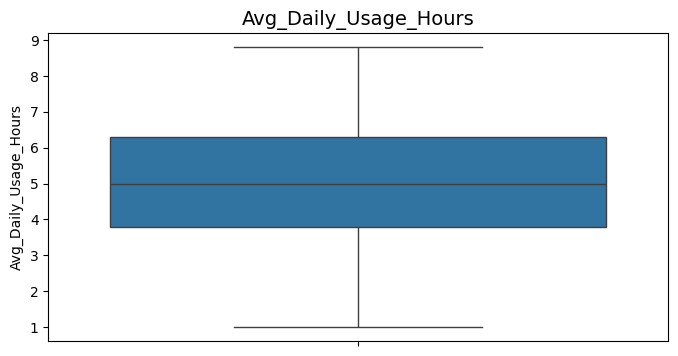

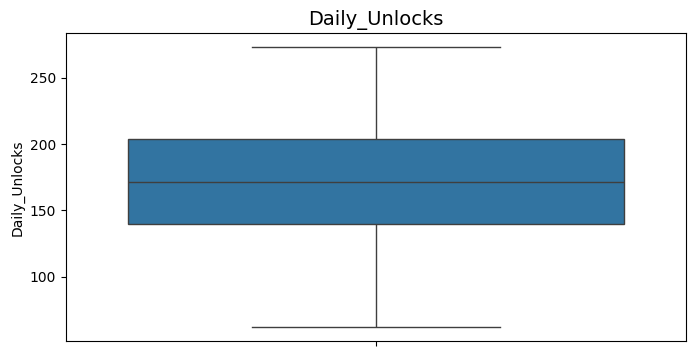

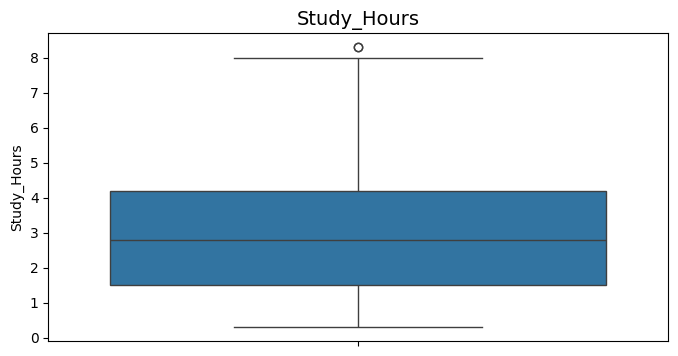

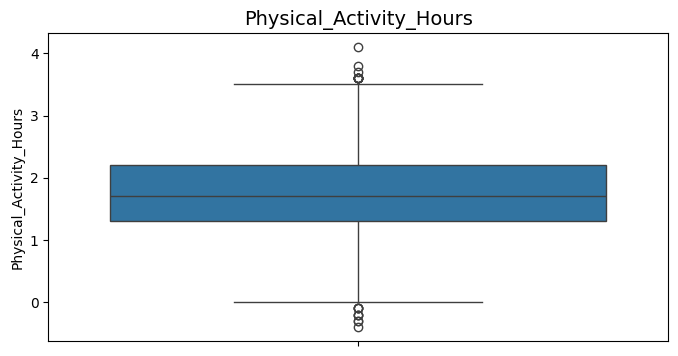

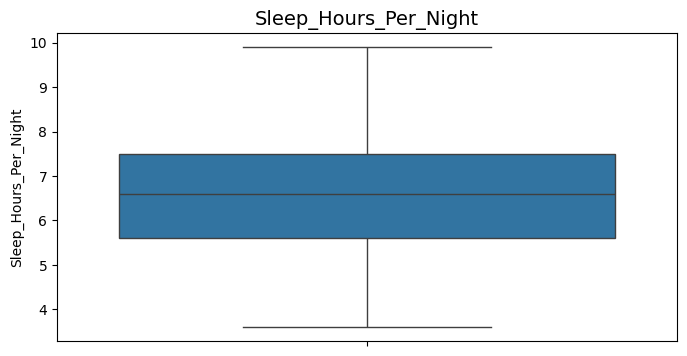

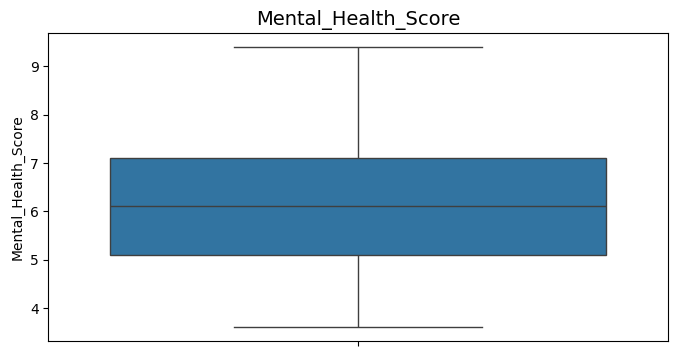

In [30]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df[col])
    plt.title(col, fontsize=14)
    plt.show()

In [31]:
df['Physical_Activity_Hours'].describe()

,Physical_Activity_Hours
count,5000.000000
mean,1.751000
std,0.668398
min,-0.400000
25%,1.300000
50%,1.700000
75%,2.200000
max,4.100000


In [32]:
df['Study_Hours'].describe()

,Study_Hours
count,5000.000000
mean,3.008420
std,1.637018
min,0.300000
25%,1.500000
50%,2.800000
75%,4.200000
max,8.300000


In [33]:
num_col=df.select_dtypes(include=['int64','float64']).columns
for col in num_col:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  outliers=df[(df[col]<lower_bound) | (df[col]>upper_bound)]
  print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
Avg_Daily_Usage_Hours: 0 outliers
Daily_Unlocks: 0 outliers
Study_Hours: 2 outliers
Physical_Activity_Hours: 22 outliers
Sleep_Hours_Per_Night: 0 outliers
Mental_Health_Score: 0 outliers


<Axes: ylabel='Physical_Activity_Hours'>

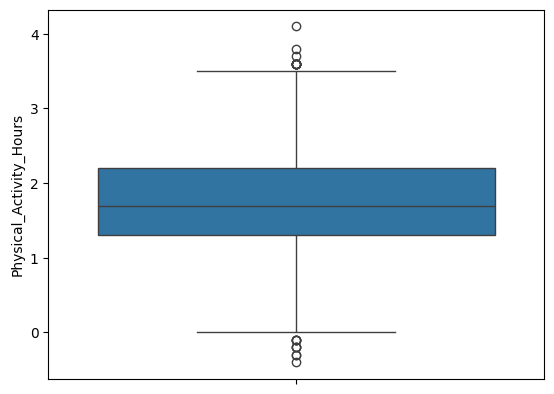

In [34]:
sns.boxplot(y=df['Physical_Activity_Hours'])

In [35]:
df=df.drop_duplicates()

In [36]:
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

<Axes: ylabel='Physical_Activity_Hours'>

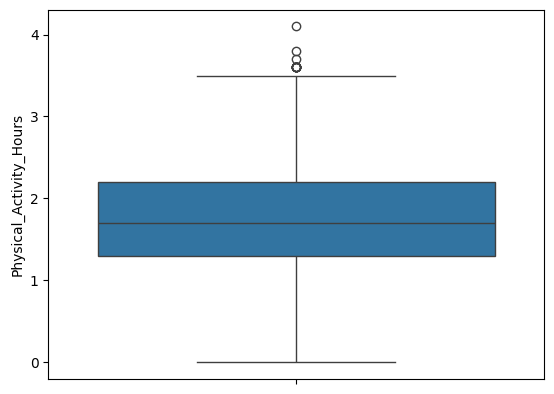

In [37]:
sns.boxplot(y=df['Physical_Activity_Hours'])

In [38]:
s=df.select_dtypes(include=['int64','float64'])
skewness_scores = s.skew()
print(skewness_scores)

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64


In [39]:
print(df['Country'].value_counts())

Country
Other        1879
India         389
USA           354
Canada        230
Australia     198
             ... 
Armenia         1
Bosnia          1
Kuwait          1
Yemen           1
Syria           1
Name: count, Length: 111, dtype: int64


In [40]:
top_countries = df['Country'].value_counts().index[:10].tolist()

In [41]:
def grouping_country(country):
  if country in top_countries:
    return country
  else:
    return 'Other'
df['Grouped_country'] = df['Country'].apply(grouping_country)

In [42]:
df['Grouped_country'].value_counts()

,count
Grouped_country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


In [43]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Grouped_country'],
      dtype='object')

In [44]:
from sklearn.model_selection import train_test_split
skwewd_col         = ['Study_Hours']
other_numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours",
                      "Sleep_Hours_Per_Night"]
ordinal_col        = ['Stress_Level']
normal_col         = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped_country"]

featured_col=skwewd_col+other_numeric_cols+ordinal_col+normal_col
X=df[featured_col]
Y=df['Mental_Health_Score']
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])

plain_numeric_pipeline = Pipeline(steps=[
    ('scale', StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

normal_pipeline = Pipeline(steps=[
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('skew', skew_pipeline, skwewd_col),
    ('plain_numeric',plain_numeric_pipeline,other_numeric_cols),
    ('ordinal', ordinal_pipeline, ordinal_col),
    ('normal', normal_pipeline, normal_col)
])

In [46]:
print(skwewd_col)
print(other_numeric_cols)
print(ordinal_col)
print(normal_col)

['Study_Hours']
['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
['Stress_Level']
['Gender', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use', 'Grouped_country']


In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_pred_train = lr_pipeline.predict(X_train)

lr_r2_testing = r2_score(y_test, lr_pred)
lr_r2_training = r2_score(y_train, lr_pred_train)
lr_mae = mean_absolute_error(y_test, lr_pred)

print(f"Accuracy of Training {lr_r2_training}")
print(f"Accuracy of Testing {lr_r2_testing}")
print(f'MAE {lr_mae}')

Accuracy of Training 0.7255672449830839
Accuracy of Testing 0.742812906901333
MAE 0.5338894857575271


In [48]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_pred_train = rf_pipeline.predict(X_train)

rf_r2_testing = r2_score(y_test, rf_pred)
rf_r2_training = r2_score(y_train, rf_pred_train)
rf_mae = mean_absolute_error(y_test, rf_pred)

print(f"Accuracy of Training {rf_r2_training}")
print(f"Accuracy of Testing {rf_r2_testing}")
print(f'MAE {rf_mae}')

Accuracy of Training 0.9827094985154842
Accuracy of Testing 0.8901510306606107
MAE 0.326722280952381


In [49]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 15],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter = 15,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs =-1 #processor free
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('skew',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('plain_numeric',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unlocks',
                                                                                'Physical_Acti...
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['Gender',
                                                                                'Academic_Level',
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Grouped_country'])])),
                                             ('model',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'model__max_depth': [5, 10, 15],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='r2')

In [50]:
random_search.best_params_

{'model__n_estimators': 300,
 'model__min_samples_split': 5,
 'model__min_samples_leaf': 2,
 'model__max_depth': 15}

In [51]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds    = rf_best_pipeline.predict(X_test)

print(f"R2 Score for random forest after hyperparameter tuning {r2_score(y_test, rf_best_preds)}")
print(f"MAE Score for random forest after hyperparameter tuning {mean_absolute_error(y_test, rf_best_preds)}")

R2 Score for random forest after hyperparameter tuning 0.8759087900091959
MAE Score for random forest after hyperparameter tuning 0.35327760771480154


In [52]:
from sklearn.metrics import mean_squared_error

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)


# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)

                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.742813     0.725567  0.533889  0.677593
1  Random Forest (default)  0.890151     0.982709  0.326722  0.442835
2    Random Forest (tuned)  0.875909     0.956398  0.353278  0.470668


In [53]:
import joblib
joblib.dump(rf_pipeline, 'Depression.pkl')

['Depression.pkl']